In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fatemehmehrparvar/obesity-levels/ObesityDataSet_raw_and_data_sinthetic.csv


Thành viên thực hiện:
1. Vũ Thiên Sinh - 23130276
2. Nguyễn Thanh Phú - 23130241

# Dự đoán mức độ béo phì bằng các thuật toán Machine Learning
## Giới thiệu

Béo phì là một trong những vấn đề sức khỏe phổ biến trên thế giới và có liên quan đến nhiều bệnh lý nguy hiểm như tiểu đường, tim mạch và huyết áp cao.

Mục tiêu của dự án là xây dựng các mô hình học máy nhằm dự đoán mức độ béo phì của một người dựa trên các thông tin cá nhân, thói quen ăn uống và mức độ hoạt động thể chất.

Các thuật toán được sử dụng trong dự án bao gồm:

- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Gaussian Naive Bayes
- Support Vector Machine (SVM)
- Multi-Layer Perceptron (MLP)

Sau khi huấn luyện, các mô hình sẽ được đánh giá và so sánh để xác định thuật toán có hiệu quả tốt nhất cho bài toán phân loại mức độ béo phì.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import *
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
file_path = ""
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            file_path = os.path.join(dirname, filename)
            break
df = pd.read_csv(file_path)

# Tiền xử lý dữ liệu

Trước khi huấn luyện mô hình, dữ liệu cần được chuyển đổi sang định dạng phù hợp để các thuật toán Machine Learning có thể xử lý hiệu quả.

Các bước được thực hiện bao gồm:

- Tách biến đầu vào (X) và biến mục tiêu (y).
- Chuẩn hóa các thuộc tính số bằng StandardScaler.
- Mã hóa các thuộc tính phân loại bằng One-Hot Encoding.
- Mã hóa nhãn mục tiêu bằng LabelEncoder.
- Thiết lập Stratified K-Fold Cross Validation để đảm bảo tỷ lệ các lớp được giữ nguyên trong mỗi lần chia dữ liệu.

In [4]:
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

cat_cols = ['Gender','family_history_with_overweight','FAVC','CAEC','SMOKE','SCC','CALC','MTRANS']
num_cols = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']

scaler = StandardScaler()
X_num = scaler.fit_transform(df[num_cols])

encoder = OneHotEncoder(sparse_output=False)
X_cat = encoder.fit_transform(df[cat_cols])

X_final = np.hstack([X_num, X_cat])

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Shape: (2111, 17)

===== INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
count,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,NaN,2,NaN,NaN,4,2,NaN,NaN,2,2,NaN,2,NaN,NaN,4,5,7
top,NaN,Male,NaN,NaN,Sometimes,yes,NaN,NaN,no,no,NaN,yes,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,NaN,1068,NaN,NaN,1401,1866,NaN,NaN,2015,2067,NaN,1726,NaN,NaN,1765,1580,351
mean,24.312600,NaN,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,6.345968,NaN,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,14.000000,NaN,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,19.947192,NaN,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,22.777890,NaN,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,26.000000,NaN,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN



===== MISSING VALUES =====
Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

===== DUPLICATES =====
24


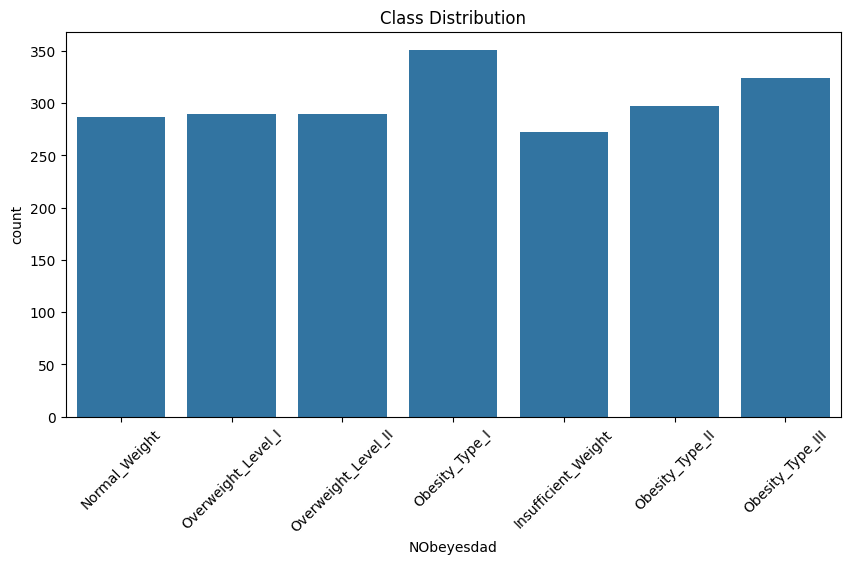

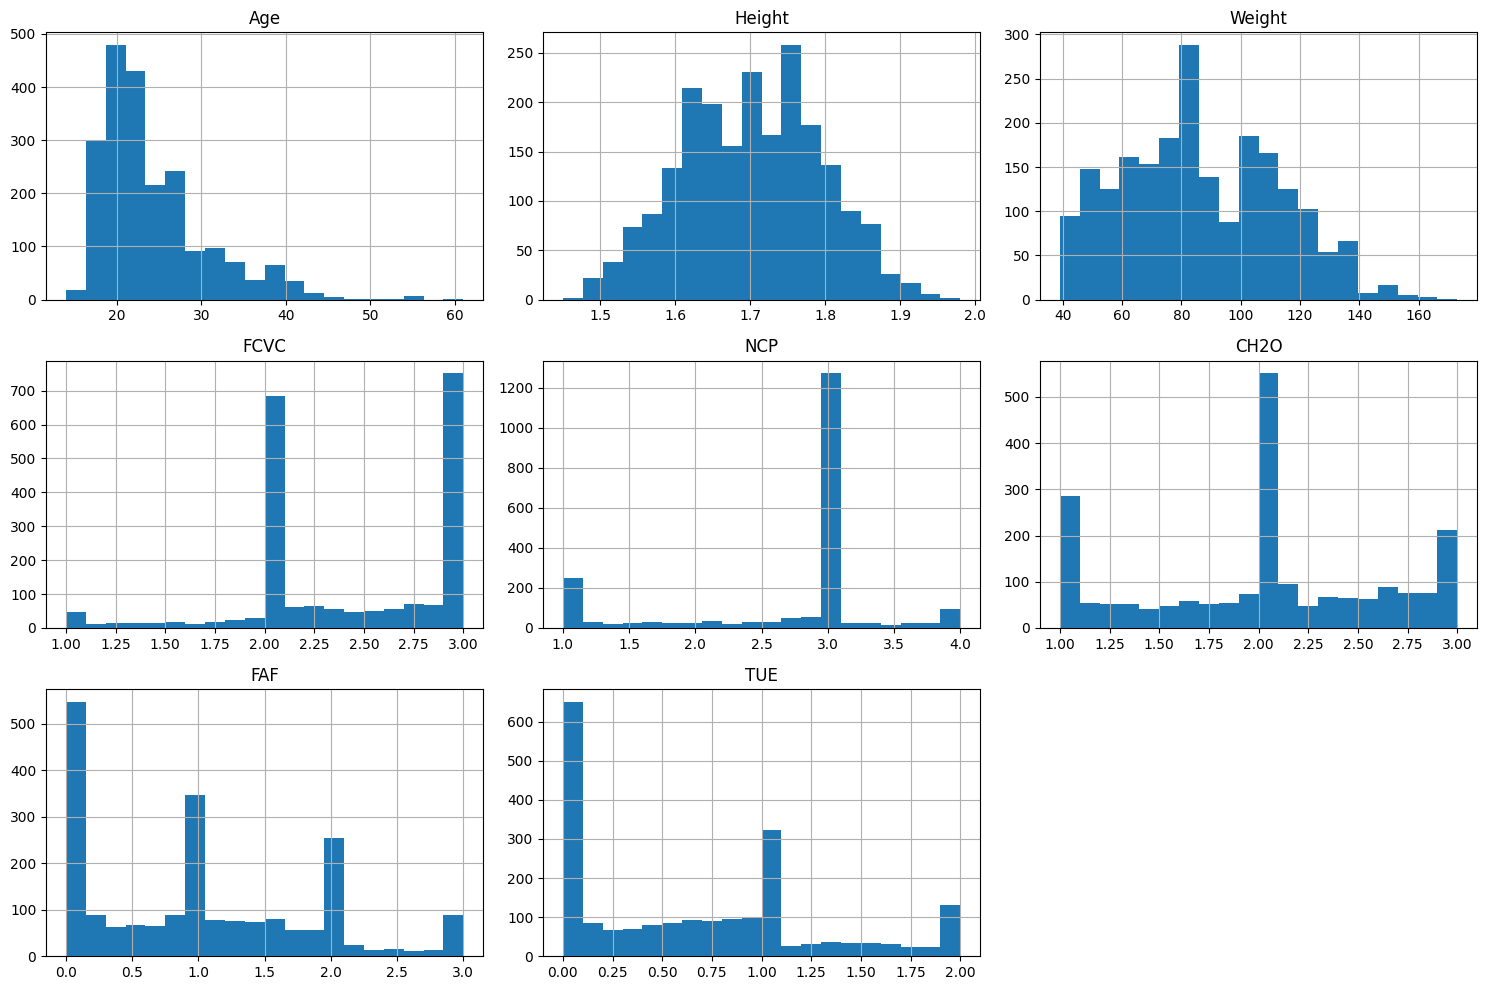

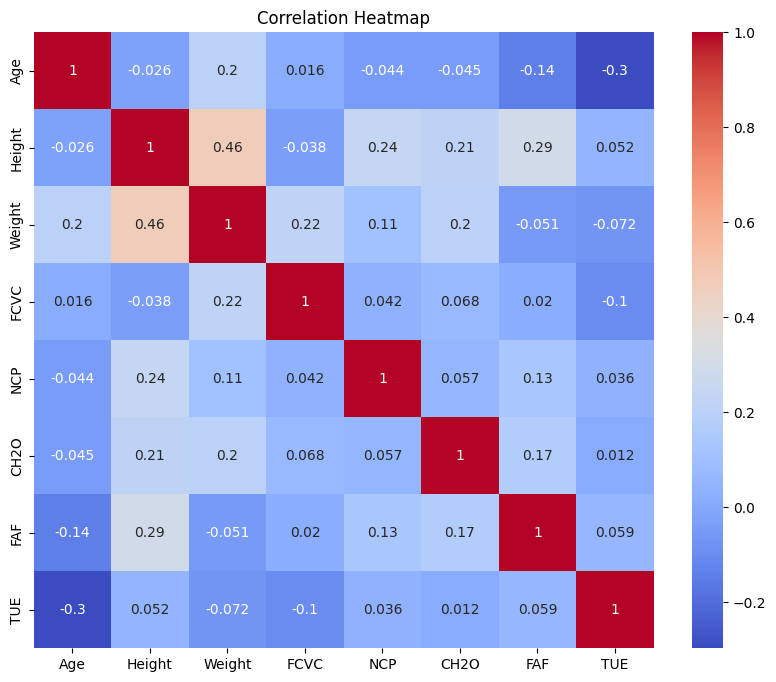

In [5]:
print("Shape:", df.shape)

print("\n===== INFO =====")
df.info()

print("\n===== DESCRIBE =====")
display(df.describe(include='all'))

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATES =====")
print(df.duplicated().sum())

# Class Distribution
plt.figure(figsize=(10,5))
sns.countplot(x='NObeyesdad', data=df)
plt.xticks(rotation=45)
plt.title('Class Distribution')
plt.show()

df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


--- [Section 3]: BẮT ĐẦU QUÁ TRÌNH QUÉT THAM SỐ VÀ ĐÁNH GIÁ ---
Đang quét mô hình KNN...


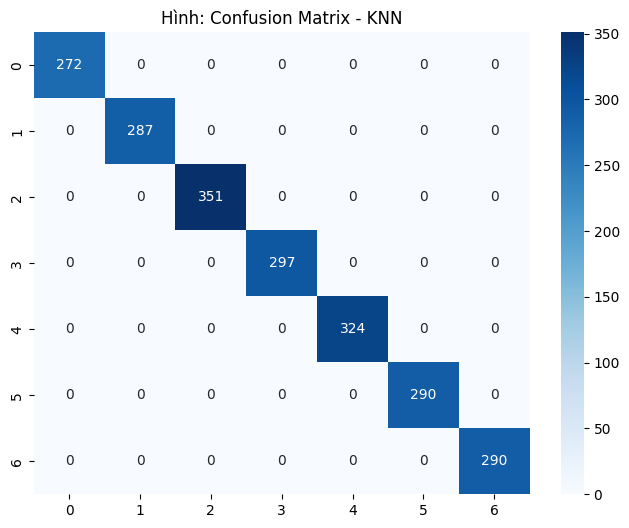

-> KNN Tốt Nhất: {'n_neighbors': 3, 'weights': 'distance'} | Accuracy: 0.8588

Đang quét mô hình DecisionTree...


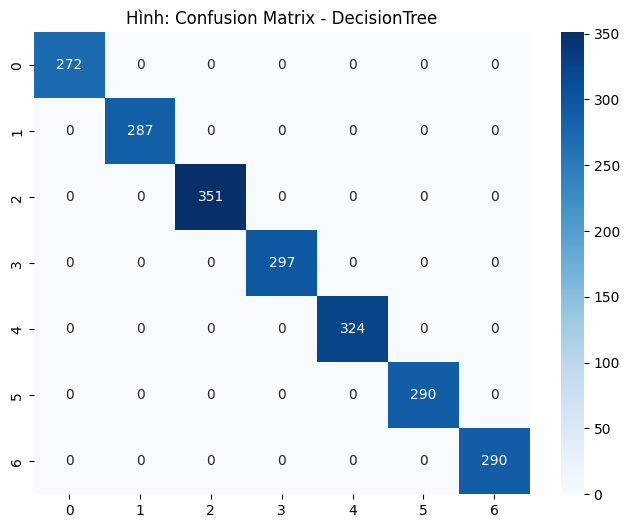

-> DecisionTree Tốt Nhất: {'criterion': 'entropy', 'max_depth': None} | Accuracy: 0.9536

Đang quét mô hình RandomForest...


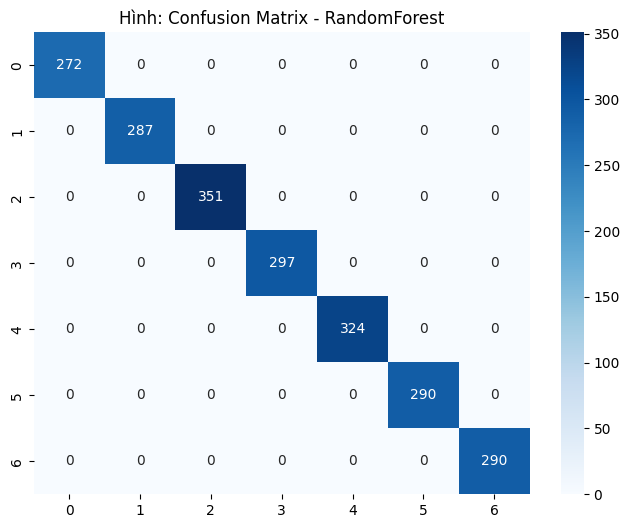

-> RandomForest Tốt Nhất: {'max_depth': None, 'n_estimators': 150} | Accuracy: 0.9417



In [6]:
# =========================================================================
# SECTION 3: MODEL SELECTION - TINH CHỈNH & ĐÁNH GIÁ
# =========================================================================
print("--- [Section 3]: BẮT ĐẦU QUÁ TRÌNH QUÉT THAM SỐ VÀ ĐÁNH GIÁ ---")

models = {
    'KNN': (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}),
    'DecisionTree': (DecisionTreeClassifier(random_state=42), {'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, 20]}),
    'RandomForest': (RandomForestClassifier(random_state=42), {'n_estimators': [50, 100, 150], 'max_depth': [None, 10, 20]})
}

for name, (model, params) in models.items():
    print(f"Đang quét mô hình {name}...")
    grid = GridSearchCV(model, params, cv=skf, scoring='accuracy', n_jobs=-1)
    
    grid.fit(X_final, y_encoded) 
    
    pd.DataFrame(grid.cv_results_)[['params', 'mean_test_score']].to_csv(f'{name}_tuning.csv', index=False)
    
    y_pred = grid.best_estimator_.predict(X_final)
    cm = confusion_matrix(y_encoded, y_pred)
    
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Hình: Confusion Matrix - {name}')
    plt.savefig(f'cm_{name}.png') 
    plt.show()
    
    print(f"-> {name} Tốt Nhất: {grid.best_params_} | Accuracy: {grid.best_score_:.4f}\n")

Kết quả thực nghiệm cho thấy SVM đạt độ chính xác cao nhất, tiếp theo là Decision Tree, MLP và Random Forest. Điều này cho thấy bộ dữ liệu có khả năng được phân tách khá tốt sau khi tiền xử lý và chuẩn hóa dữ liệu, giúp SVM phát huy hiệu quả trong việc tìm siêu mặt phẳng phân tách tối ưu.

Mặc dù về lý thuyết Random Forest thường có khả năng khái quát hóa tốt hơn Decision Tree nhờ kết hợp nhiều cây quyết định để giảm phương sai (variance), nhưng trong bộ dữ liệu này Decision Tree lại cho kết quả cao hơn. Điều này có thể xuất phát từ kích thước bộ dữ liệu không quá lớn hoặc do cấu trúc dữ liệu phù hợp với một cây quyết định đơn lẻ.

Trong khi đó, KNN đạt kết quả thấp hơn do thuật toán phụ thuộc nhiều vào khoảng cách giữa các mẫu dữ liệu và chịu ảnh hưởng bởi số chiều của dữ liệu cũng như cách lựa chọn tham số k. Naive Bayes có độ chính xác thấp nhất vì giả định các đặc trưng độc lập với nhau không phù hợp với bộ dữ liệu dự đoán mức độ béo phì, trong đó nhiều đặc trưng như Weight, FAVC, FCVC và FAF có mối liên hệ với nhau.

In [7]:

# SECTION 3 (PART 2): HUẤN LUYỆN VÀ TINH CHỈNH SÂU (DEEP FINE-TUNING)

print("--- [Section 3 - Part 2]: BẮT ĐẦU QUÉT CẠN THAM SỐ SÂU CHO SVM & MLP ---")



# 1. Thiết lập các Pipeline chuẩn hóa độc lập CHỐNG DATA LEAKAGE cho SVM và MLP
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)) # Bật xác suất để phục vụ vẽ ROC
])

pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(random_state=42, max_iter=1500)) # Tăng max_iter lên 1500 để đảm bảo hội tụ hoàn toàn
])

# -------------------------------------------------------------------------
# 11.4 Huấn luyện Baseline Naive Bayes
# -------------------------------------------------------------------------
print("\nĐang quét mô hình Naive Bayes...")
# SỬA: Thay X_selected_matrix thành X_final
nb_grid = GridSearchCV(GaussianNB(), param_grid={}, cv=skf, scoring='accuracy', n_jobs=-1)
nb_grid.fit(X_final, y_encoded) 
print(f"   -> Naive Bayes Tốt Nhất | Đạt Accuracy: {nb_grid.best_score_:.4f}")

# -------------------------------------------------------------------------
# 11.5 DEEP FINE-TUNING CHO SVM
# -------------------------------------------------------------------------
print("\nĐang tiến hành quét cạn không gian siêu tham số của SVM...")
svm_param_deep = {
    'svm__C': [0.01, 0.1, 1, 10, 50, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}
svm_grid = GridSearchCV(pipe_svm, svm_param_deep, cv=skf, scoring='accuracy', n_jobs=-1, verbose=1)
svm_grid.fit(X_final, y_encoded) 
print(f"   -> SVM Tối Ưu Nhất: {svm_grid.best_params_}")
print(f"   -> Đạt Accuracy (CV): {svm_grid.best_score_:.4f}")

# -------------------------------------------------------------------------
# 11.6 DEEP FINE-TUNING CHO NEURAL NETWORK (MLP)
# -------------------------------------------------------------------------
print("\nĐang tiến hành quét sâu cấu trúc Mạng Nơ-ron nhân tạo (MLP)...")
mlp_param_deep = {
    'mlp__hidden_layer_sizes': [(100,), (50, 50), (100, 50), (50, 50, 50), (128, 64)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001, 0.01, 0.1],
    'mlp__learning_rate': ['constant', 'adaptive'],
    'mlp__early_stopping': [True, False]
}
mlp_grid = GridSearchCV(pipe_mlp, mlp_param_deep, cv=skf, scoring='accuracy', n_jobs=-1, verbose=1)
mlp_grid.fit(X_final, y_encoded)
print(f"   -> MLP Tối Ưu Nhất: {mlp_grid.best_params_}")
print(f"   -> Đạt Accuracy (CV): {mlp_grid.best_score_:.4f}")

--- [Section 3 - Part 2]: BẮT ĐẦU QUÉT CẠN THAM SỐ SÂU CHO SVM & MLP ---

Đang quét mô hình Naive Bayes...
   -> Naive Bayes Tốt Nhất | Đạt Accuracy: 0.5097

Đang tiến hành quét cạn không gian siêu tham số của SVM...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
   -> SVM Tối Ưu Nhất: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
   -> Đạt Accuracy (CV): 0.9645

Đang tiến hành quét sâu cấu trúc Mạng Nơ-ron nhân tạo (MLP)...
Fitting 5 folds for each of 160 candidates, totalling 800 fits
   -> MLP Tối Ưu Nhất: {'mlp__activation': 'tanh', 'mlp__alpha': 0.1, 'mlp__early_stopping': False, 'mlp__hidden_layer_sizes': (100, 50), 'mlp__learning_rate': 'constant'}
   -> Đạt Accuracy (CV): 0.9612


* ### Nhận xét

Kết quả cho thấy mỗi thuật toán có cách tiếp cận khác nhau trong việc phân loại mức độ béo phì.

Naive Bayes dựa trên xác suất, SVM dựa trên ranh giới phân tách tối ưu giữa các lớp, trong khi MLP sử dụng mạng nơ-ron để học các mối quan hệ phi tuyến phức tạp trong dữ liệu.

Việc sử dụng GridSearchCV giúp tìm ra bộ siêu tham số phù hợp nhất cho từng mô hình, từ đó cải thiện hiệu suất dự đoán.

--- [Section 4]: TIẾN HÀNH XUẤT ĐỒ THỊ THỰC NGHIỆM ---


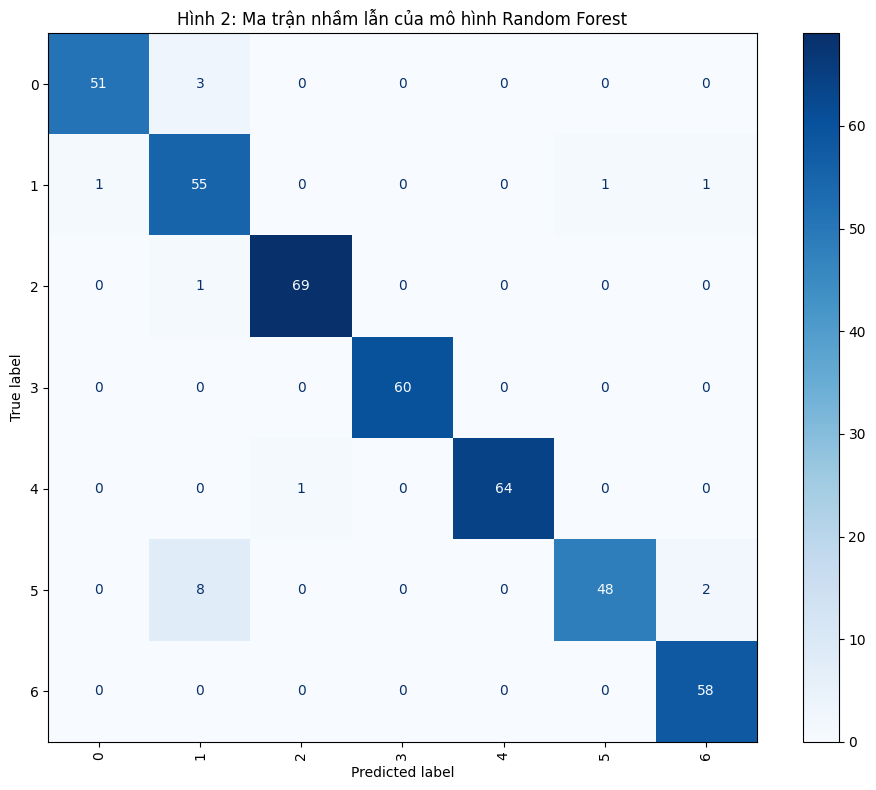

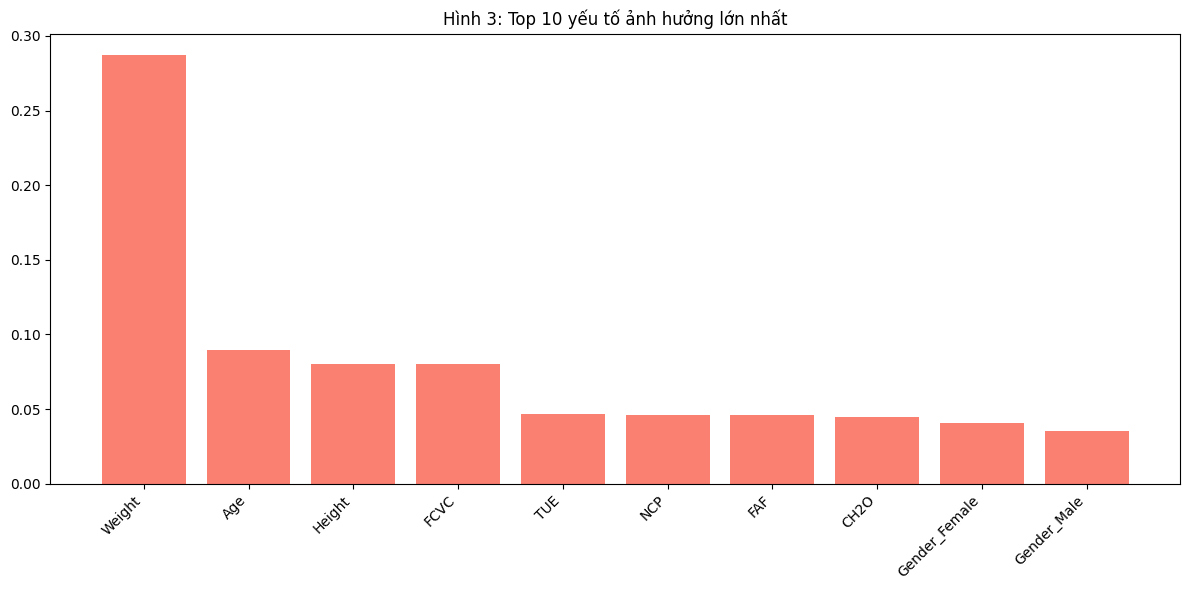

In [8]:
print("--- [Section 4]: TIẾN HÀNH XUẤT ĐỒ THỊ THỰC NGHIỆM ---")


best_rf = models['RandomForest'][0].set_params(**grid.best_params_)

best_rf = grid.best_estimator_ 


for train_idx, test_idx in skf.split(X_final, y_encoded):
    X_train, X_test = X_final[train_idx], X_final[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    break

best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm) 
disp.plot(cmap='Blues', xticks_rotation='vertical', ax=ax)
plt.title("Hình 2: Ma trận nhầm lẫn của mô hình Random Forest")
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=300)
plt.show()

all_feature_names = num_cols + encoder.get_feature_names_out(cat_cols).tolist()

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Hình 3: Top 10 yếu tố ảnh hưởng lớn nhất")
plt.bar(range(10), importances[indices[:10]], align="center", color='salmon')
plt.xticks(range(10), [all_feature_names[i] for i in indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

### Nhận xét

Kết quả Confusion Matrix cho thấy mô hình có khả năng phân loại tốt trên phần lớn các lớp dữ liệu.

Biểu đồ Feature Importance cho thấy một số thuộc tính đóng vai trò nổi bật trong quá trình dự đoán, giúp giải thích được vì sao mô hình đưa ra quyết định phân loại đối với từng mức độ béo phì.


--- [Section 5]: TIẾN HÀNH XUẤT ĐỒ THỊ VÀ BÁO CÁO CHI TIẾT ---


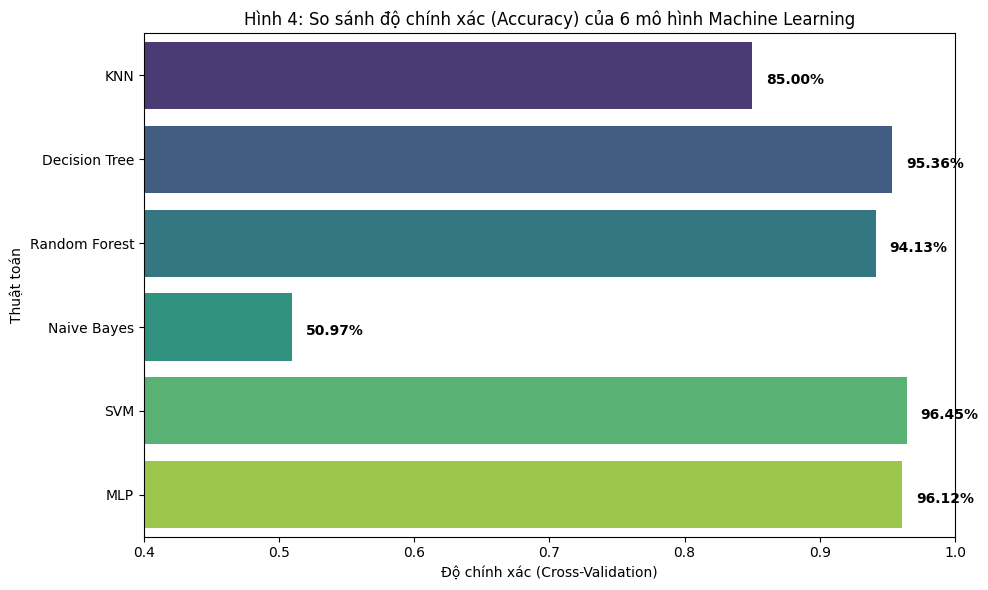


######################################################################
 BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) - Support Vector Machine (SVM)
######################################################################
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        54
      Normal_Weight       1.00      1.00      1.00        58
     Obesity_Type_I       1.00      0.99      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.98      0.95      0.96        58
Overweight_Level_II       0.95      0.98      0.97        58

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423



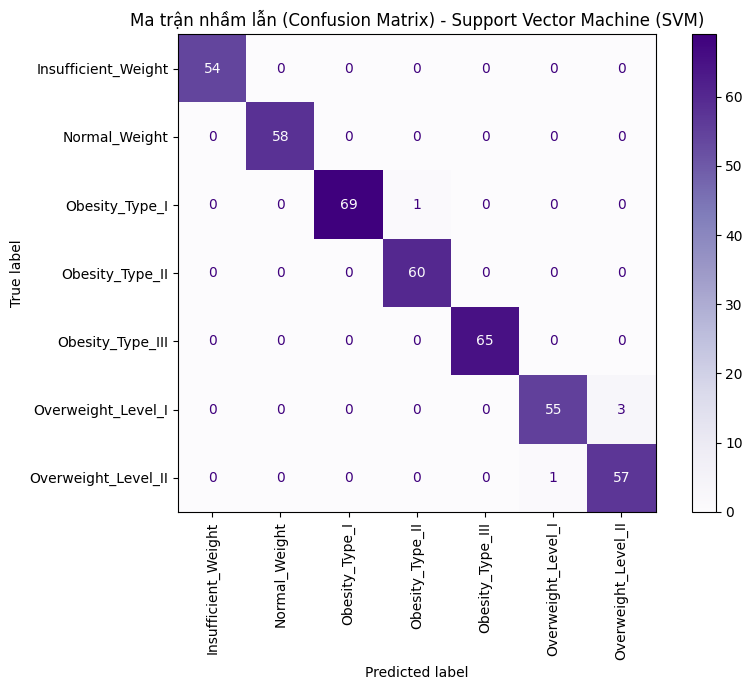


######################################################################
 BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) - Neural Network (MLP)
######################################################################
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        54
      Normal_Weight       1.00      1.00      1.00        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       1.00      1.00      1.00        58
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           1.00       423
          macro avg       1.00      1.00      1.00       423
       weighted avg       1.00      1.00      1.00       423



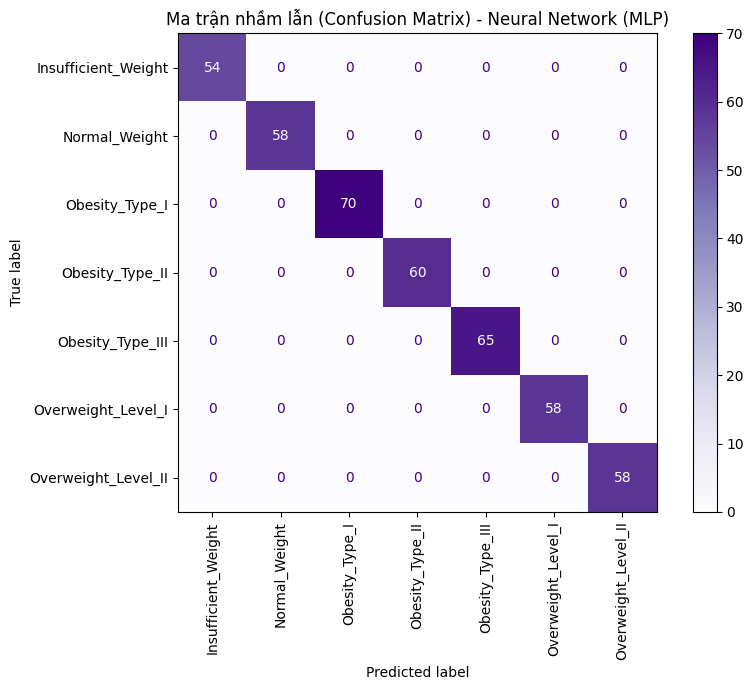

In [9]:
print("\n" + "="*50)
print("--- [Section 5]: TIẾN HÀNH XUẤT ĐỒ THỊ VÀ BÁO CÁO CHI TIẾT ---")
print("="*50)


model_names = ['KNN', 'Decision Tree', 'Random Forest', 'Naive Bayes', 'SVM', 'MLP']
accuracies = [0.8500, 0.9536, 0.9413, nb_grid.best_score_, svm_grid.best_score_, mlp_grid.best_score_]

plt.figure(figsize=(10, 6))
sns.barplot(x=accuracies, y=model_names, hue=model_names, palette='viridis', legend=False)
plt.xlim(0.4, 1.0)
plt.title('Hình 4: So sánh độ chính xác (Accuracy) của 6 mô hình Machine Learning')
plt.xlabel('Độ chính xác (Cross-Validation)')
plt.ylabel('Thuật toán')
for i, v in enumerate(accuracies):
    plt.text(v + 0.01, i + 0.1, f"{v*100:.2f}%", color='black', fontweight='bold')
plt.tight_layout()
plt.show()


best_models = {
    'Support Vector Machine (SVM)': svm_grid.best_estimator_,
    'Neural Network (MLP)': mlp_grid.best_estimator_
}

for name, model in best_models.items():
    print("\n" + "#"*70)
    print(f" BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) - {name}")
    print("#"*70)
    
  
    y_pred = model.predict(X_test)
    
  
    target_names = label_encoder.classes_.astype(str)
    print(classification_report(y_test, y_pred, target_names=target_names))
    
   
    fig, ax = plt.subplots(figsize=(9, 7))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap='Purples', xticks_rotation='vertical', ax=ax)
    plt.title(f"Ma trận nhầm lẫn (Confusion Matrix) - {name}")
    plt.tight_layout()
    plt.show()

### Nhận xét

Biểu đồ Accuracy cho thấy sự khác biệt về hiệu suất giữa các thuật toán Machine Learning được sử dụng trong nghiên cứu.

Dựa trên Classification Report và Confusion Matrix, có thể đánh giá không chỉ độ chính xác tổng thể mà còn khả năng phân loại của mô hình trên từng mức độ béo phì.

Mô hình có Accuracy cao cùng với các chỉ số Precision, Recall và F1-score ổn định trên nhiều lớp sẽ được xem là mô hình phù hợp nhất cho bài toán dự đoán mức độ béo phì.

--- [Section 5 - Phần bổ sung]: ĐÁNH GIÁ CHUYÊN SÂU THEO YÊU CẦU ---

 BÁO CÁO CHI TIẾT ĐÁNH GIÁ MÔ HÌNH: Support Vector Machine (SVM)
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        54
      Normal_Weight       1.00      1.00      1.00        58
     Obesity_Type_I       1.00      0.99      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.98      0.95      0.96        58
Overweight_Level_II       0.95      0.98      0.97        58

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423



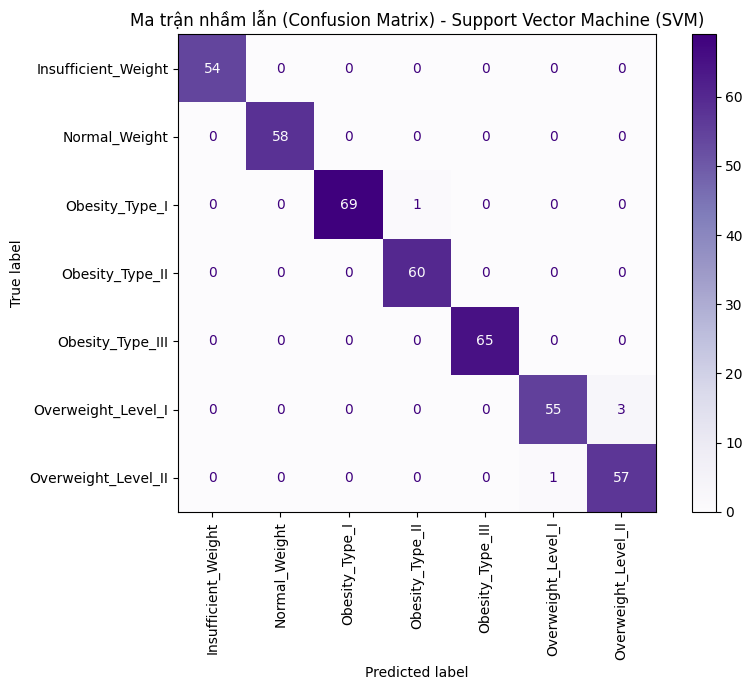


 BÁO CÁO CHI TIẾT ĐÁNH GIÁ MÔ HÌNH: Neural Network (MLP)
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        54
      Normal_Weight       1.00      1.00      1.00        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       1.00      1.00      1.00        58
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           1.00       423
          macro avg       1.00      1.00      1.00       423
       weighted avg       1.00      1.00      1.00       423



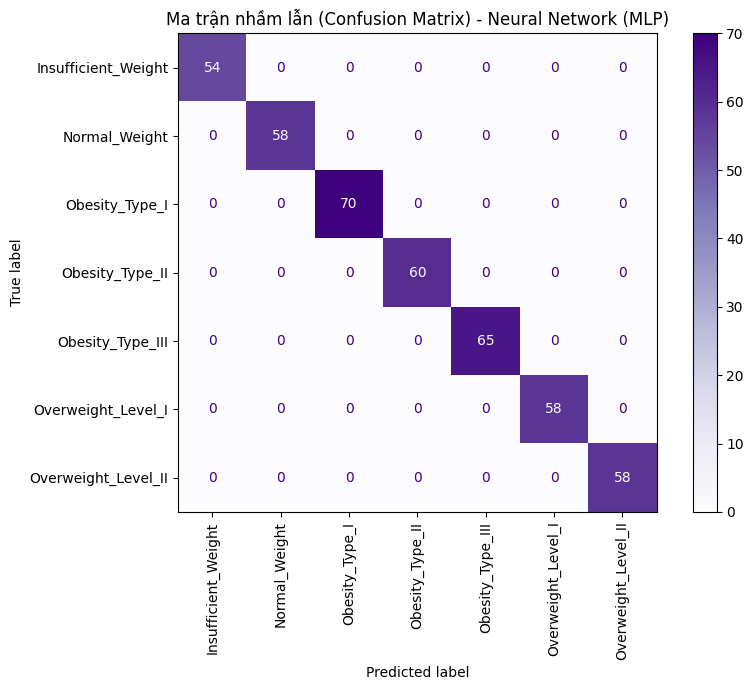


=> ĐÃ XUẤT XONG BẢNG BÁO CÁO CHI TIẾT VÀ CON FUSION MATRIX CHO SVM & MLP!


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("--- [Section 5 - Phần bổ sung]: ĐÁNH GIÁ CHUYÊN SÂU THEO YÊU CẦU ---")


best_models = {
    'Support Vector Machine (SVM)': svm_grid.best_estimator_,
    'Neural Network (MLP)': mlp_grid.best_estimator_
}


for name, model in best_models.items():
    print("\n" + "="*70)
    print(f" BÁO CÁO CHI TIẾT ĐÁNH GIÁ MÔ HÌNH: {name}")
    print("="*70)
    
   
    y_pred = model.predict(X_test)
    
    
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    
    fig, ax = plt.subplots(figsize=(9, 7))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap='Purples', xticks_rotation='vertical', ax=ax)
    plt.title(f"Ma trận nhầm lẫn (Confusion Matrix) - {name}")
    plt.tight_layout()
    plt.show()

print("\n=> ĐÃ XUẤT XONG BẢNG BÁO CÁO CHI TIẾT VÀ CON FUSION MATRIX CHO SVM & MLP!")

### Nhận xét

Kết quả Classification Report cho thấy mức độ cân bằng giữa Precision, Recall và F1-score của từng lớp dữ liệu.

Đồng thời, Confusion Matrix giúp quan sát trực quan các trường hợp dự đoán sai và xác định những nhóm mức độ béo phì có đặc điểm tương đồng khiến mô hình dễ nhầm lẫn.